# Car Price Prediction using Machine Learning

## Author: Sariya Khan

### Project Objective

The goal of this project is to predict the selling price of used cars using Machine Learning.

The project includes:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Training
- Model Evaluation
- Price Prediction

Tools Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn



In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
# Load Dataset

df = pd.read_csv("car data.csv")

In [3]:
# Display First 5 Rows

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# Display Last 5 Rows

df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [5]:
# Dataset Shape

df.shape

(301, 9)

In [6]:
# Column Names

df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='str')

In [7]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [8]:
# Statistical Summary

df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
# Check Missing Values

df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [10]:
# Check Duplicate Records

df.duplicated().sum()

np.int64(2)

In [11]:
# Remove Duplicate Rows

df.drop_duplicates(inplace=True)

In [12]:
# Verify Shape Again

df.shape

(299, 9)

# Feature Engineering

We will create a new feature called Car_Age.

Car age is more useful than manufacturing year when predicting resale value.

In [13]:
# Create Car Age Feature

df["Car_Age"] = 2025 - df["Year"]

In [14]:
# Display Dataset

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


In [15]:
# Remove Year Column

df.drop("Year", axis=1, inplace=True)

In [16]:
# Check Unique Fuel Types

df["Fuel_Type"].unique()

<ArrowStringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str

In [17]:
# Check Unique Selling Types

df["Selling_type"].unique()

<ArrowStringArray>
['Dealer', 'Individual']
Length: 2, dtype: str

# Encoding Categorical Features

Machine Learning algorithms cannot understand text values.

We will convert categorical data into numerical form using Label Encoding.

In [18]:
# Create Label Encoder

encoder = LabelEncoder()

In [19]:
# Encode Fuel Type

df["Fuel_Type"] = encoder.fit_transform(df["Fuel_Type"])

In [20]:
# Encode Selling Type

df["Selling_type"] = encoder.fit_transform(df["Selling_type"])

In [21]:
# Encode Transmission

df["Transmission"] = encoder.fit_transform(df["Transmission"])

In [22]:
# Display Encoded Dataset

df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,2,0,1,0,11
1,sx4,4.75,9.54,43000,1,0,1,0,12
2,ciaz,7.25,9.85,6900,2,0,1,0,8
3,wagon r,2.85,4.15,5200,2,0,1,0,14
4,swift,4.60,6.87,42450,1,0,1,0,11


# Exploratory Data Analysis (EDA)

EDA helps us understand the relationships, distributions, and patterns in the dataset before building the machine learning model.

In [23]:
# Remove Car Name Column

df.drop("Car_Name", axis=1, inplace=True)

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,11
1,4.75,9.54,43000,1,0,1,0,12
2,7.25,9.85,6900,2,0,1,0,8
3,2.85,4.15,5200,2,0,1,0,14
4,4.60,6.87,42450,1,0,1,0,11


In [24]:
# Check Updated Columns

df.columns

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type',
       'Selling_type', 'Transmission', 'Owner', 'Car_Age'],
      dtype='str')

# Distribution of Selling Price

Let's understand how the selling prices are distributed in the dataset.

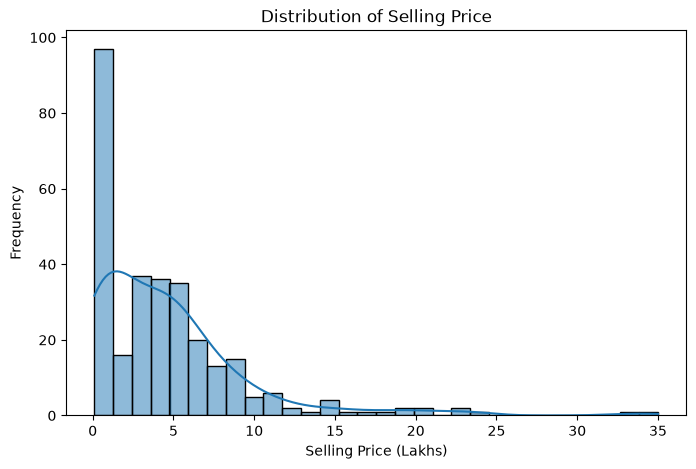

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], bins=30, kde=True)

plt.title("Distribution of Selling Price")

plt.xlabel("Selling Price (Lakhs)")

plt.ylabel("Frequency")

plt.show()

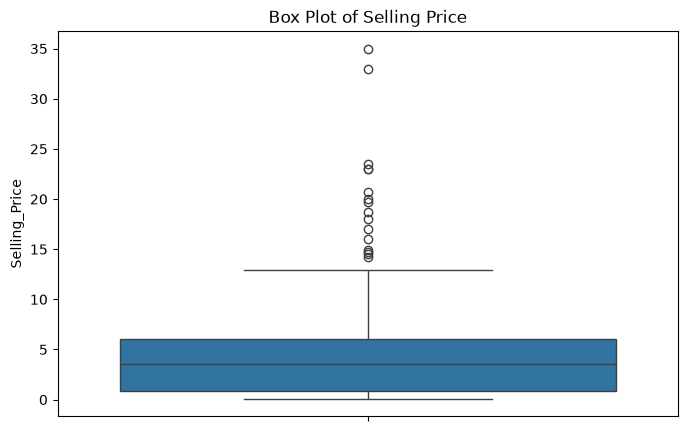

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Selling_Price"])

plt.title("Box Plot of Selling Price")

plt.show()

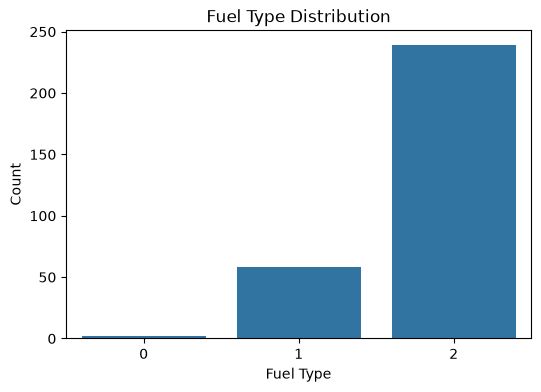

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(x="Fuel_Type", data=df)

plt.title("Fuel Type Distribution")

plt.xlabel("Fuel Type")

plt.ylabel("Count")

plt.show()

# Transmission Type Distribution

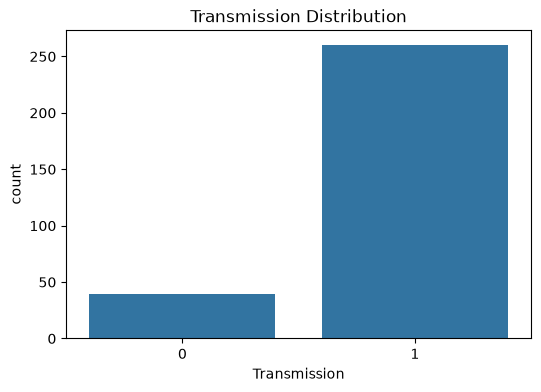

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x="Transmission", data=df)

plt.title("Transmission Distribution")

plt.show()

# Selling Type Distribution

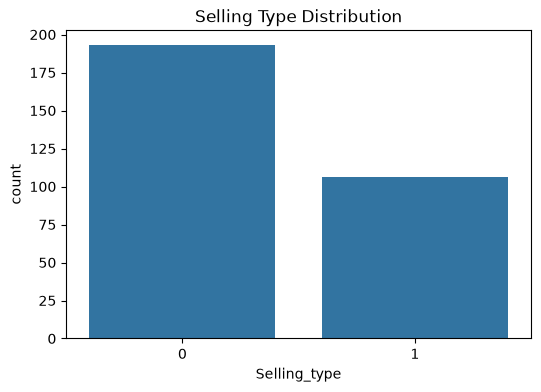

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(x="Selling_type", data=df)

plt.title("Selling Type Distribution")

plt.show()

# Scatter Plot: Present Price vs Selling Price

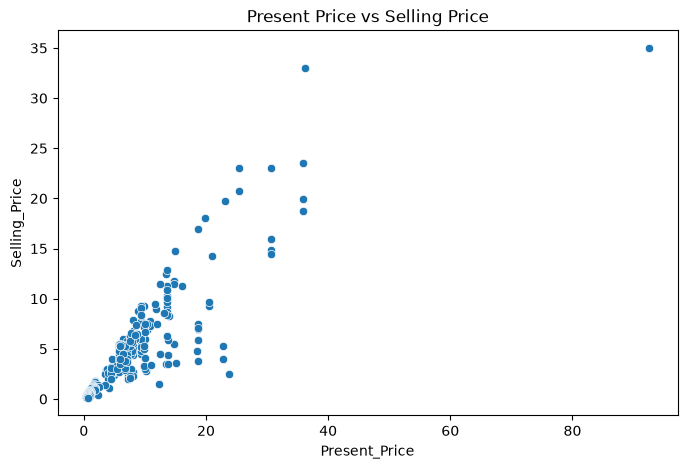

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Present_Price",
    y="Selling_Price",
    data=df
)

plt.title("Present Price vs Selling Price")

plt.show()

# Scatter Plot: Car Age vs Selling Price

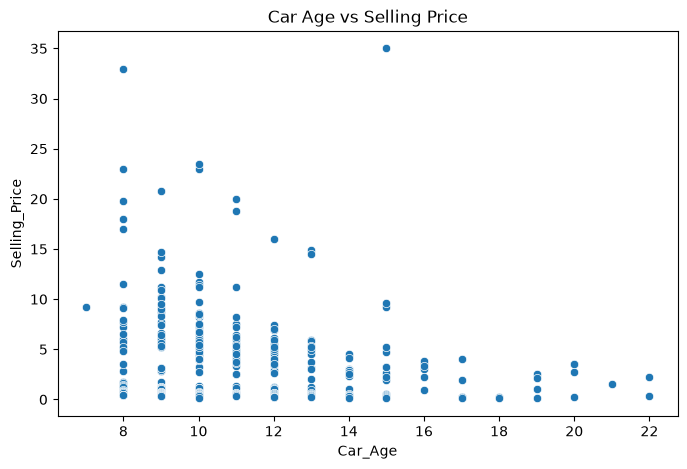

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Car_Age",
    y="Selling_Price",
    data=df
)

plt.title("Car Age vs Selling Price")

plt.show()

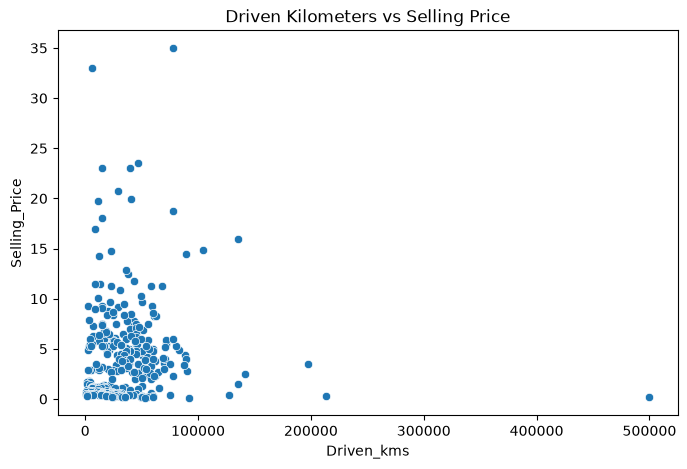

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Driven_kms",
    y="Selling_Price",
    data=df
)

plt.title("Driven Kilometers vs Selling Price")

plt.show()

# Correlation Heatmap

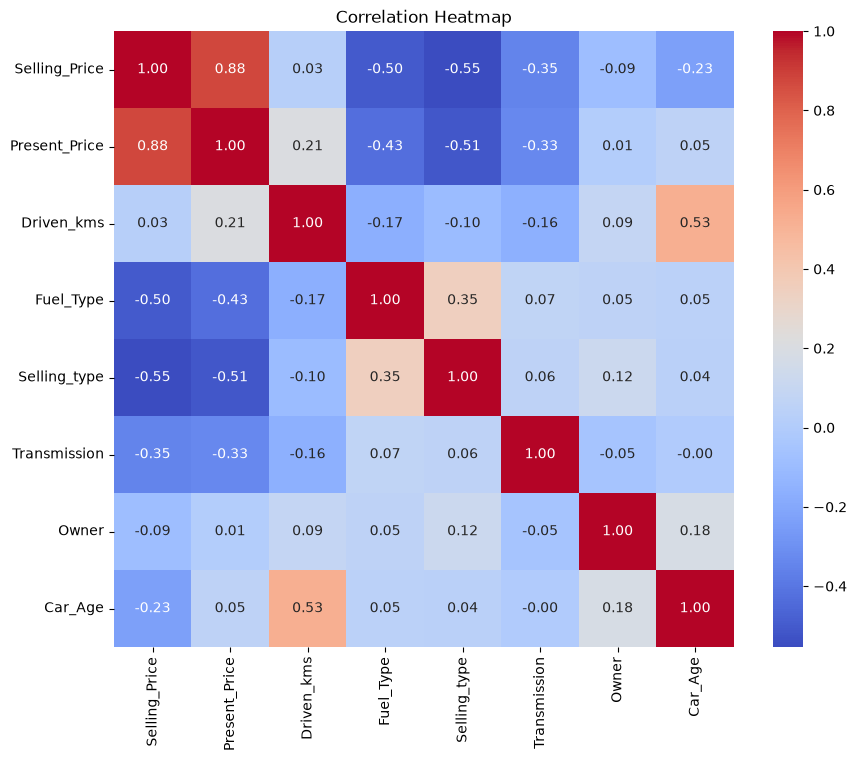

In [33]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Pair Plot

A pair plot helps visualize pairwise relationships between multiple variables.

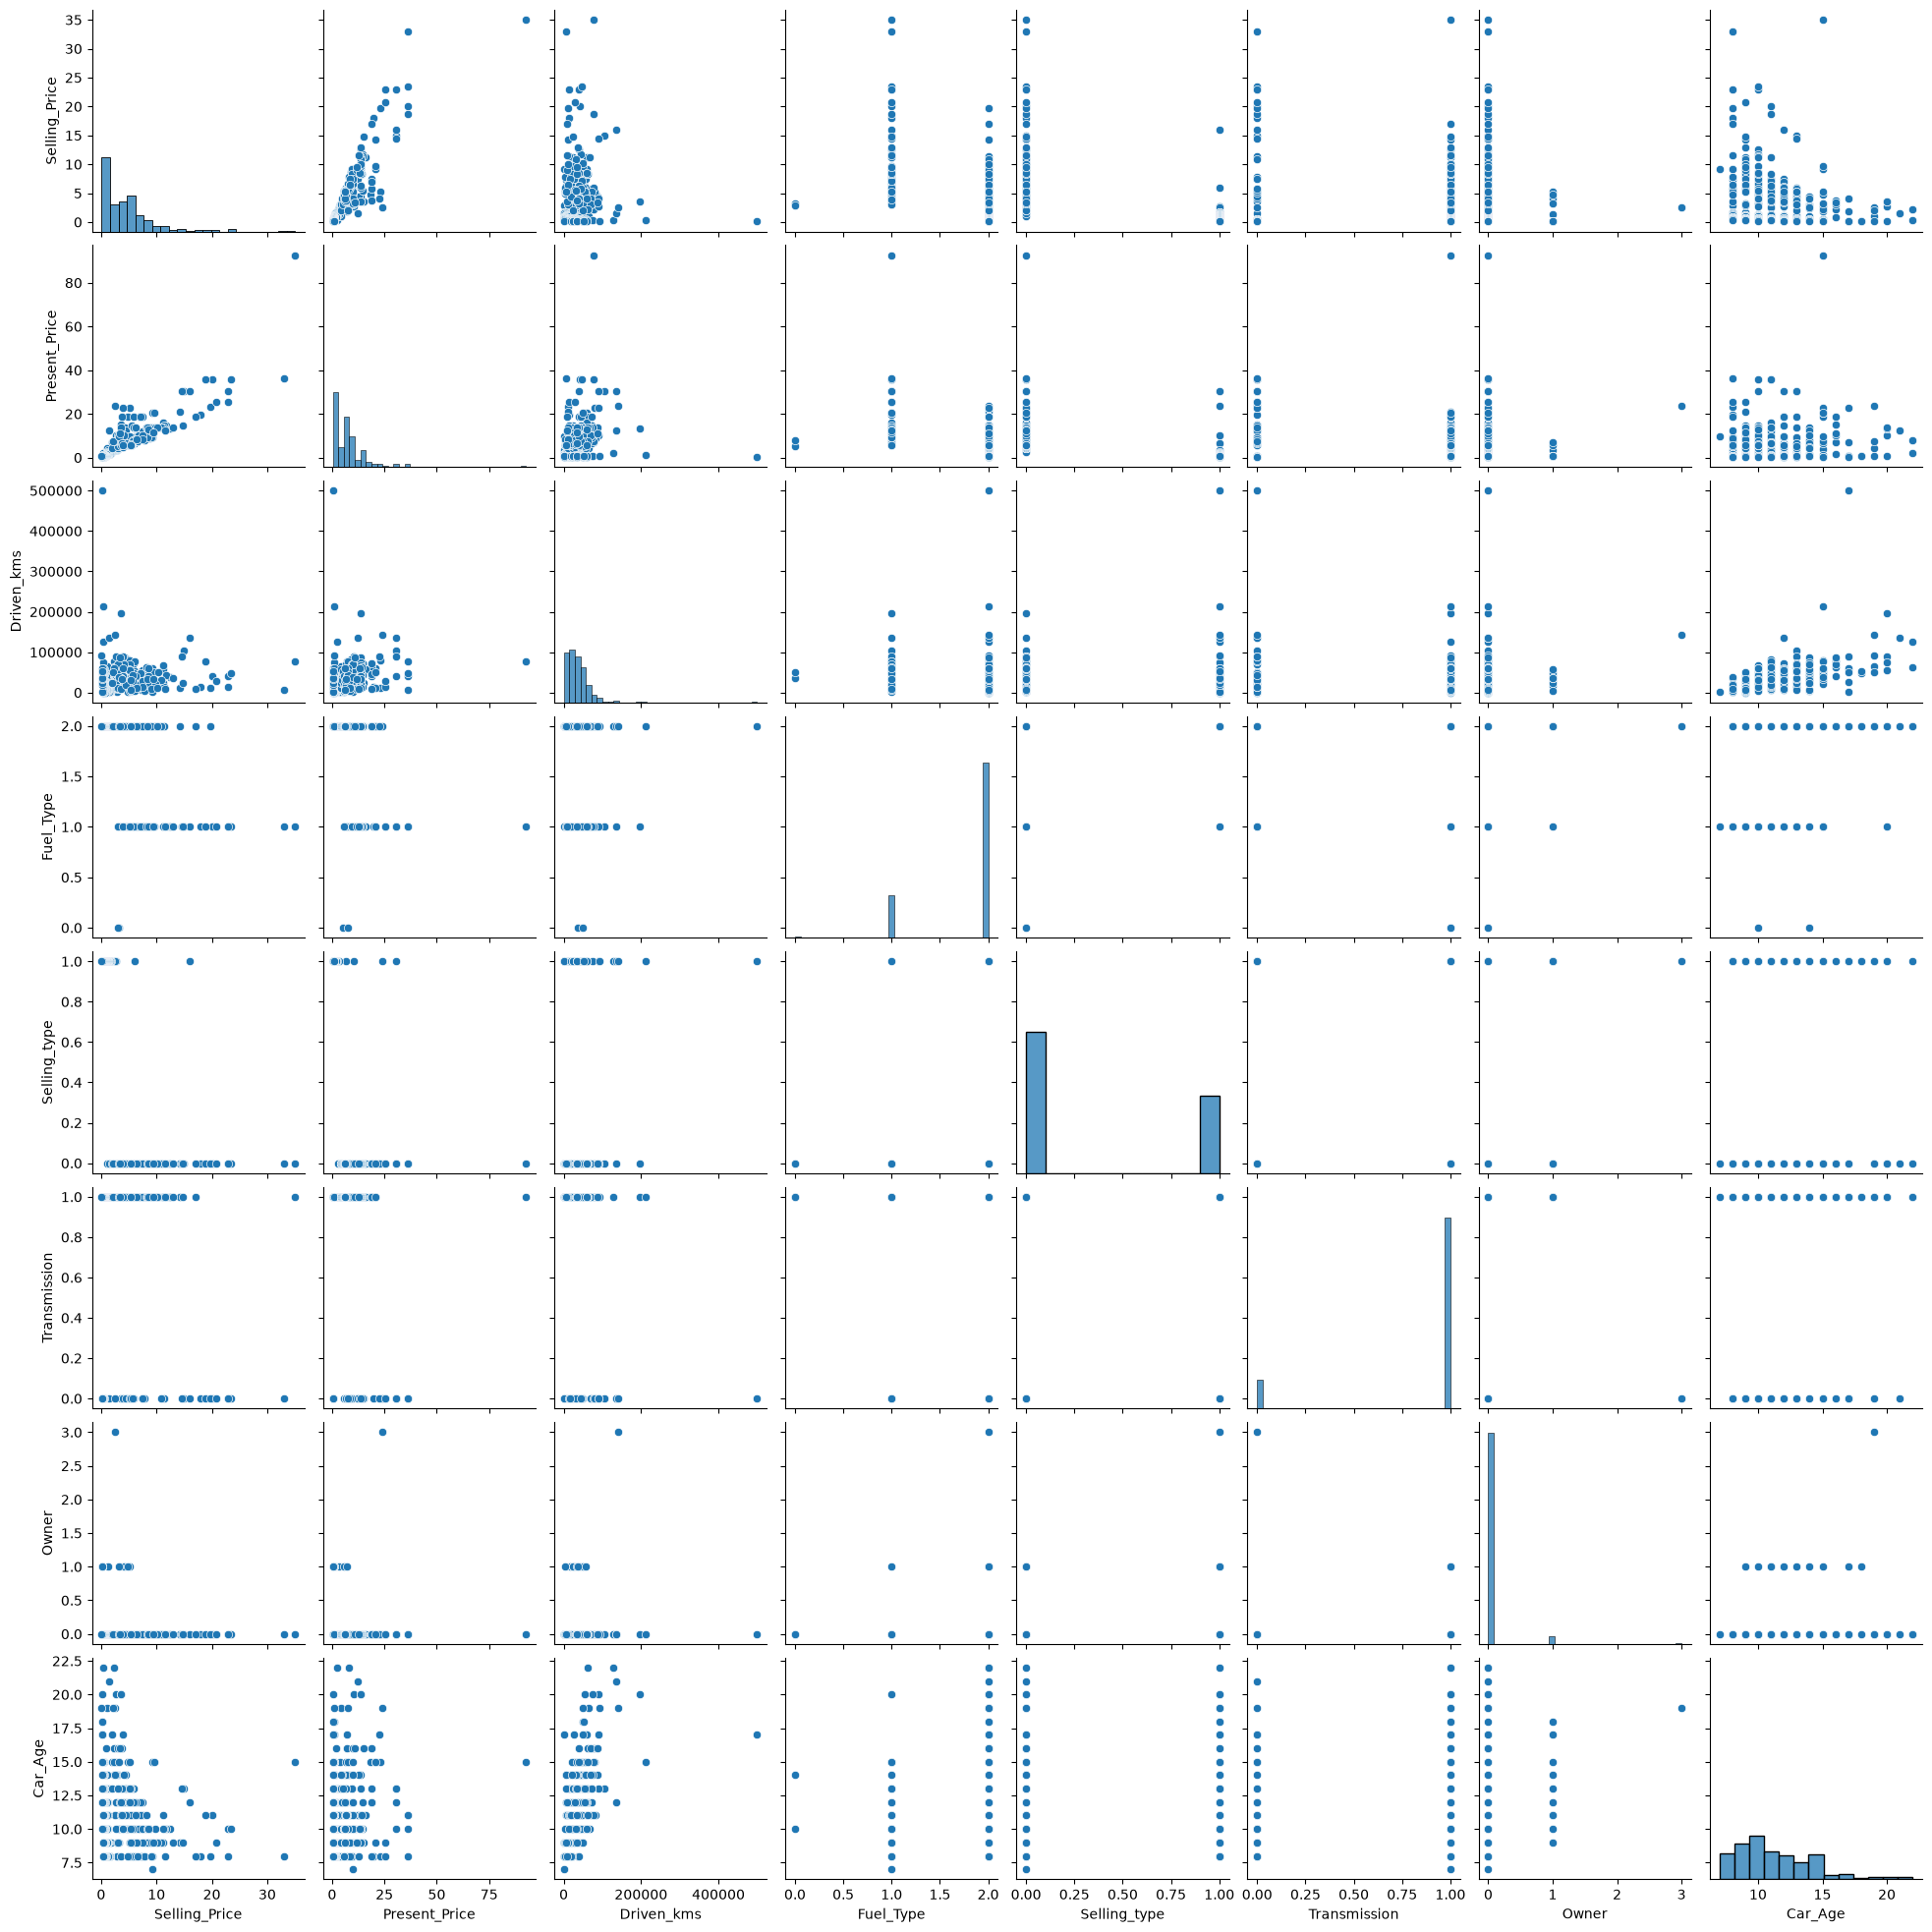

In [34]:
sns.pairplot(df)

plt.show()

In [35]:
# Check Final Dataset

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,11
1,4.75,9.54,43000,1,0,1,0,12
2,7.25,9.85,6900,2,0,1,0,8
3,2.85,4.15,5200,2,0,1,0,14
4,4.60,6.87,42450,1,0,1,0,11


# Summary of EDA

Key observations:

- Present Price has a strong positive relationship with Selling Price.
- Older cars generally have lower selling prices.
- Cars with higher driven kilometers tend to have lower resale values.
- The correlation heatmap helps identify the most influential features.
- The dataset is now ready for machine learning.

# Feature Selection

In Machine Learning, we divide the dataset into:

- Features (X): Independent variables used for prediction.
- Target (y): The value we want to predict, which is the Selling Price.

In [36]:
# Define Features and Target

X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

In [37]:
# Display Features

X.head()

,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,5.59,27000,2,0,1,0,11
1,9.54,43000,1,0,1,0,12
2,9.85,6900,2,0,1,0,8
3,4.15,5200,2,0,1,0,14
4,6.87,42450,1,0,1,0,11


In [38]:
# Display Target Variable

y.head()

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

# Split the Dataset

The dataset will be divided into:

- 80% Training Data
- 20% Testing Data

Training data teaches the model, while testing data evaluates its performance.

In [39]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [40]:
# Check Dataset Shapes

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (239, 7)
Testing Features: (60, 7)
Training Labels: (239,)
Testing Labels: (60,)


# Build the Linear Regression Model

Linear Regression is used because Selling Price is a continuous numerical value.

In [41]:
# Create Model

model = LinearRegression()

In [42]:
# Train Model

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.44,-0. ,-1.22,...,-1.58, 0.7 ,-0.34]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Present_Price','Driven_kms','Fuel_Type',...,'Transmission','Owner', 'Car_Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.525
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


# Make Predictions

Now the trained model predicts selling prices for the test data.

In [43]:
# Predict Prices

y_pred = model.predict(X_test)

In [44]:
# Compare Actual and Predicted Prices

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,8.99,7.540145
1,8.35,7.607943
2,0.45,1.360867
3,7.45,6.838162
4,5.25,11.264332
5,5.25,4.543315
6,5.85,8.583769
7,1.15,1.707565
8,9.25,8.645293
9,0.38,-0.941602


# Evaluate the Model

We will evaluate the model using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [45]:
# Mean Absolute Error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.5408119549693524


In [46]:
# Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 6.675444100492251


In [47]:
# Root Mean Squared Error

rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 2.5836880811143303


In [48]:
# R² Score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.7409934356413543


# Visualize Predictions

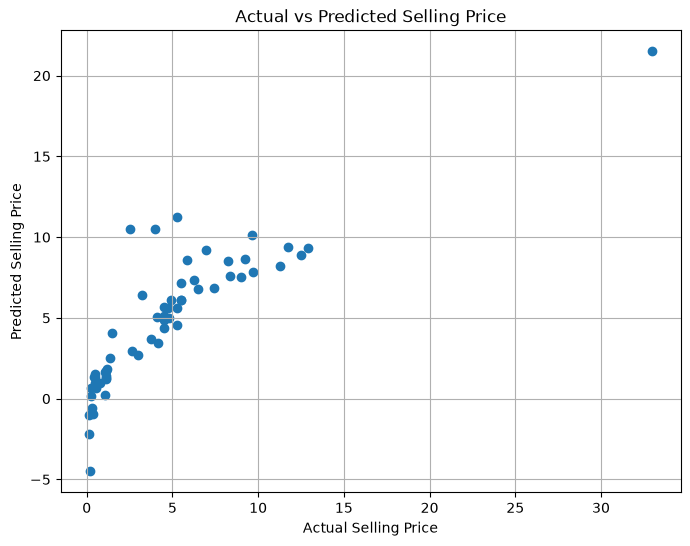

In [49]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Selling Price")

plt.ylabel("Predicted Selling Price")

plt.title("Actual vs Predicted Selling Price")

plt.grid(True)

plt.show()

# Residual Analysis

Residual = Actual Price − Predicted Price

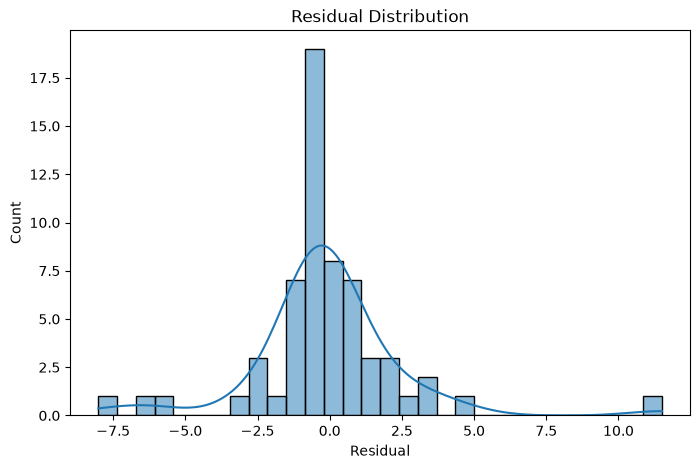

In [50]:
# Calculate Residuals

residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.show()

# Save the Trained Model

The trained model will be saved so that it can be used later in the Streamlit web application without retraining.

In [51]:
import joblib

joblib.dump(model, "model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [53]:
# Verify Model File

import os

print(os.listdir())

['.git', '.gitignore', '.venv', 'app.py', 'car data.csv', 'Car_Price_Prediction.ipynb', 'model.pkl', 'README.md', 'requirements.txt']


# Machine Learning Summary

In this section:

- Selected input features and target variable.
- Split the data into training and testing sets.
- Built and trained a Linear Regression model.
- Generated predictions.
- Evaluated performance using MAE, MSE, RMSE, and R² Score.
- Saved the trained model for deployment.

